In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/tdmpc2/")

import matplotlib.pyplot as plt
import numpy as np
import pickle
from tqdm import tqdm
import pandas as pd
import json
from pathlib import Path

import numpy as np
import seaborn as sns
import os
from analysis.utils import load_sweep_metadata, load_data, compute_success, chunk_data
from analysis.utils_decoding import evaluate_lags_leave_k_out

## Load data

In [3]:
import pickle

# Load vars_tdmpc2_vs_dreamer.pkl data
with open(
        '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_tdmpc2_vs_dreamer/vars_tdmpc2_vs_dreamer.pkl',
        'rb') as f:
    vars_tdmpc2_vs_dreamer = pickle.load(f)

In [4]:
vars_to_chunk = [
    'z_dreamer_onehot',
    'z_dreamer_onehot_stochastic',
    'z_dreamer_onehot_deterministic',
    'z_dreamer_soft',
    'z_dreamer_soft_stochastic',
    'z_dreamer_soft_deterministic',
]

for var in vars_to_chunk:
    vars_tdmpc2_vs_dreamer[var] = np.array_split(vars_tdmpc2_vs_dreamer[var],
                                                 15)


## Decoding

In [5]:
# vars_all = {
#     'z_tdmpc2_state':
#         zs_tdmpc2,
#     'z_sac':
#         zs_sac,
#     'obs': [obs_episode for obs_episode in obs_episodes],
#     'position': [
#         obs_episode[:, 0].reshape(-1, 1) for obs_episode in obs_episodes
#     ],
#     'cos(pole_angle)': [
#         obs_episode[:, 1].reshape(-1, 1) for obs_episode in obs_episodes
#     ],
#     'sin(pole_angle)': [
#         obs_episode[:, 2].reshape(-1, 1) for obs_episode in obs_episodes
#     ],
#     'cart_velocity': [
#         obs_episode[:, 3].reshape(-1, 1) for obs_episode in obs_episodes
#     ],
#     'pole_angular_velocity': [
#         obs_episode[:, 4].reshape(-1, 1) for obs_episode in obs_episodes
#     ],
#     'rewards': [
#         rewards_episode.reshape(-1, 1) for rewards_episode in rewards_episodes
#     ],
#     'actions': [
#         actions_episode.reshape(-1, 1) for actions_episode in actions_episodes
#     ],
# }

In [6]:
# import os
# import pickle

# # Save vars_all to disk
# save_path = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_sac_vs_tdmpc2/passive_data'
# os.makedirs(save_path, exist_ok=True)

# with open(os.path.join(save_path, 'vars_all.pkl'), 'wb') as f:
#     pickle.dump(vars_all, f)

# print(f"Saved vars_all to {save_path}")


In [7]:
decoding_relationships = [
    # ('z', 'obs'),
    # ('obs', 'obs'),
    # ('position', 'position'),
    # ('cos(pole_angle)', 'cos(pole_angle)'),
    # ('sin(pole_angle)', 'sin(pole_angle)'),
    # ('cart_velocity', 'cart_velocity'),
    # ('pole_angular_velocity', 'pole_angular_velocity'),
    # ('rewards', 'rewards'),
    # ('actions', 'actions'),
    ('z_dreamer_soft', 'position'),
    ('z_dreamer_soft', 'cos(pole_angle)'),
    ('z_dreamer_soft', 'sin(pole_angle)'),
    ('z_dreamer_soft', 'cart_velocity'),
    ('z_dreamer_soft', 'pole_angular_velocity'),
    ('z_dreamer_soft', 'rewards'),
    ('z_dreamer_soft', 'actions'),

    # ('z_sac', 'position'),
    # ('z_sac', 'cos(pole_angle)'),
    # ('z_sac', 'sin(pole_angle)'),
    # ('z_sac', 'cart_velocity'),
    # ('z_sac', 'pole_angular_velocity'),
    # ('z_sac', 'rewards'),
    # ('z_sac', 'actions'),
]


In [8]:
np.arange(-60, 61, 20),

(array([-60, -40, -20,   0,  20,  40,  60]),)

In [ ]:
path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_tdmpc2_vs_dreamer'
#path_to_save = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/pytorch_sac/analysis/'
#'sac': vars_sac,

for model in ['linear_regression']:
    for predict_type in ['future']:
        results_decoding = {}
        for x_var, y_var in decoding_relationships:
            print(f"Decoding {x_var} -> {y_var}")
            results_decoding[f'{x_var}-{y_var}'] = evaluate_lags_leave_k_out(
                vars_tdmpc2_vs_dreamer[x_var],
                vars_tdmpc2_vs_dreamer[y_var],
                model=model,
                lags=np.arange(-60, 61, 10),
                k_holdout=1,
                add_bootstrap_ci=True,
                shuffle_X=False,
                shuffle_y=False,
                predict_difference=True
                if predict_type == 'difference' else False,
                standardize_X=True
            )  #NOTE: I'm standardizing the X data, but not the y data

        #Save results_decoding to pickle file
        with open(
                os.path.join(
                    path_to_save,
                    f'results_decoding_{predict_type}_{model}_passive_data_dreamer.pkl'
                ), 'wb') as f:
            pickle.dump(results_decoding, f)

## Plotting

In [15]:
import pickle

path_tdmpc2 = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_pixel_vs_state/results_decoding_future_linear_regression_passive_data_pixel_vs_state.pkl'
path_dreamer = '/home/hgf_hmgu/hgf_gib4562/tdmpc2/analysis/outputs_tdmpc2_vs_dreamer/results_decoding_future_linear_regression_passive_data_dreamer.pkl'

with open(path_tdmpc2, 'rb') as f:
    results_decoding_tdmpc2 = pickle.load(f)

with open(path_dreamer, 'rb') as f:
    results_decoding_dreamer = pickle.load(f)

results_decoding_all = {**results_decoding_tdmpc2, **results_decoding_dreamer}
results_decoding_all.keys()


dict_keys(['position-position', 'cos(pole_angle)-cos(pole_angle)', 'sin(pole_angle)-sin(pole_angle)', 'cart_velocity-cart_velocity', 'pole_angular_velocity-pole_angular_velocity', 'rewards-rewards', 'actions-actions', 'z_tdmpc2_state-position', 'z_tdmpc2_state-cos(pole_angle)', 'z_tdmpc2_state-sin(pole_angle)', 'z_tdmpc2_state-cart_velocity', 'z_tdmpc2_state-pole_angular_velocity', 'z_tdmpc2_state-rewards', 'z_tdmpc2_state-actions', 'z_tdmpc2_pixel-position', 'z_tdmpc2_pixel-cos(pole_angle)', 'z_tdmpc2_pixel-sin(pole_angle)', 'z_tdmpc2_pixel-cart_velocity', 'z_tdmpc2_pixel-pole_angular_velocity', 'z_tdmpc2_pixel-rewards', 'z_tdmpc2_pixel-actions', 'z_dreamer_soft-position', 'z_dreamer_soft-cos(pole_angle)', 'z_dreamer_soft-sin(pole_angle)', 'z_dreamer_soft-cart_velocity', 'z_dreamer_soft-pole_angular_velocity', 'z_dreamer_soft-rewards', 'z_dreamer_soft-actions'])

In [16]:
decoding_relationships = [
    ('z', 'obs'),
    ('obs', 'obs'),
    ('position', 'position'),
    ('cos(pole_angle)', 'cos(pole_angle)'),
    ('sin(pole_angle)', 'sin(pole_angle)'),
    ('cart_velocity', 'cart_velocity'),
    ('pole_angular_velocity', 'pole_angular_velocity'),
    ('rewards', 'rewards'),
    ('actions', 'actions'),
    ('z_dreamer_soft', 'position'),
    ('z_dreamer_soft', 'cos(pole_angle)'),
    ('z_dreamer_soft', 'sin(pole_angle)'),
    ('z_dreamer_soft', 'cart_velocity'),
    ('z_dreamer_soft', 'pole_angular_velocity'),
    ('z_dreamer_soft', 'rewards'),
    ('z_dreamer_soft', 'actions'),
    ('z_tdmpc2_state', 'position'),
    ('z_tdmpc2_state', 'cos(pole_angle)'),
    ('z_tdmpc2_state', 'sin(pole_angle)'),
    ('z_tdmpc2_state', 'cart_velocity'),
    ('z_tdmpc2_state', 'pole_angular_velocity'),
    ('z_tdmpc2_state', 'rewards'),
    ('z_tdmpc2_state', 'actions'),
]

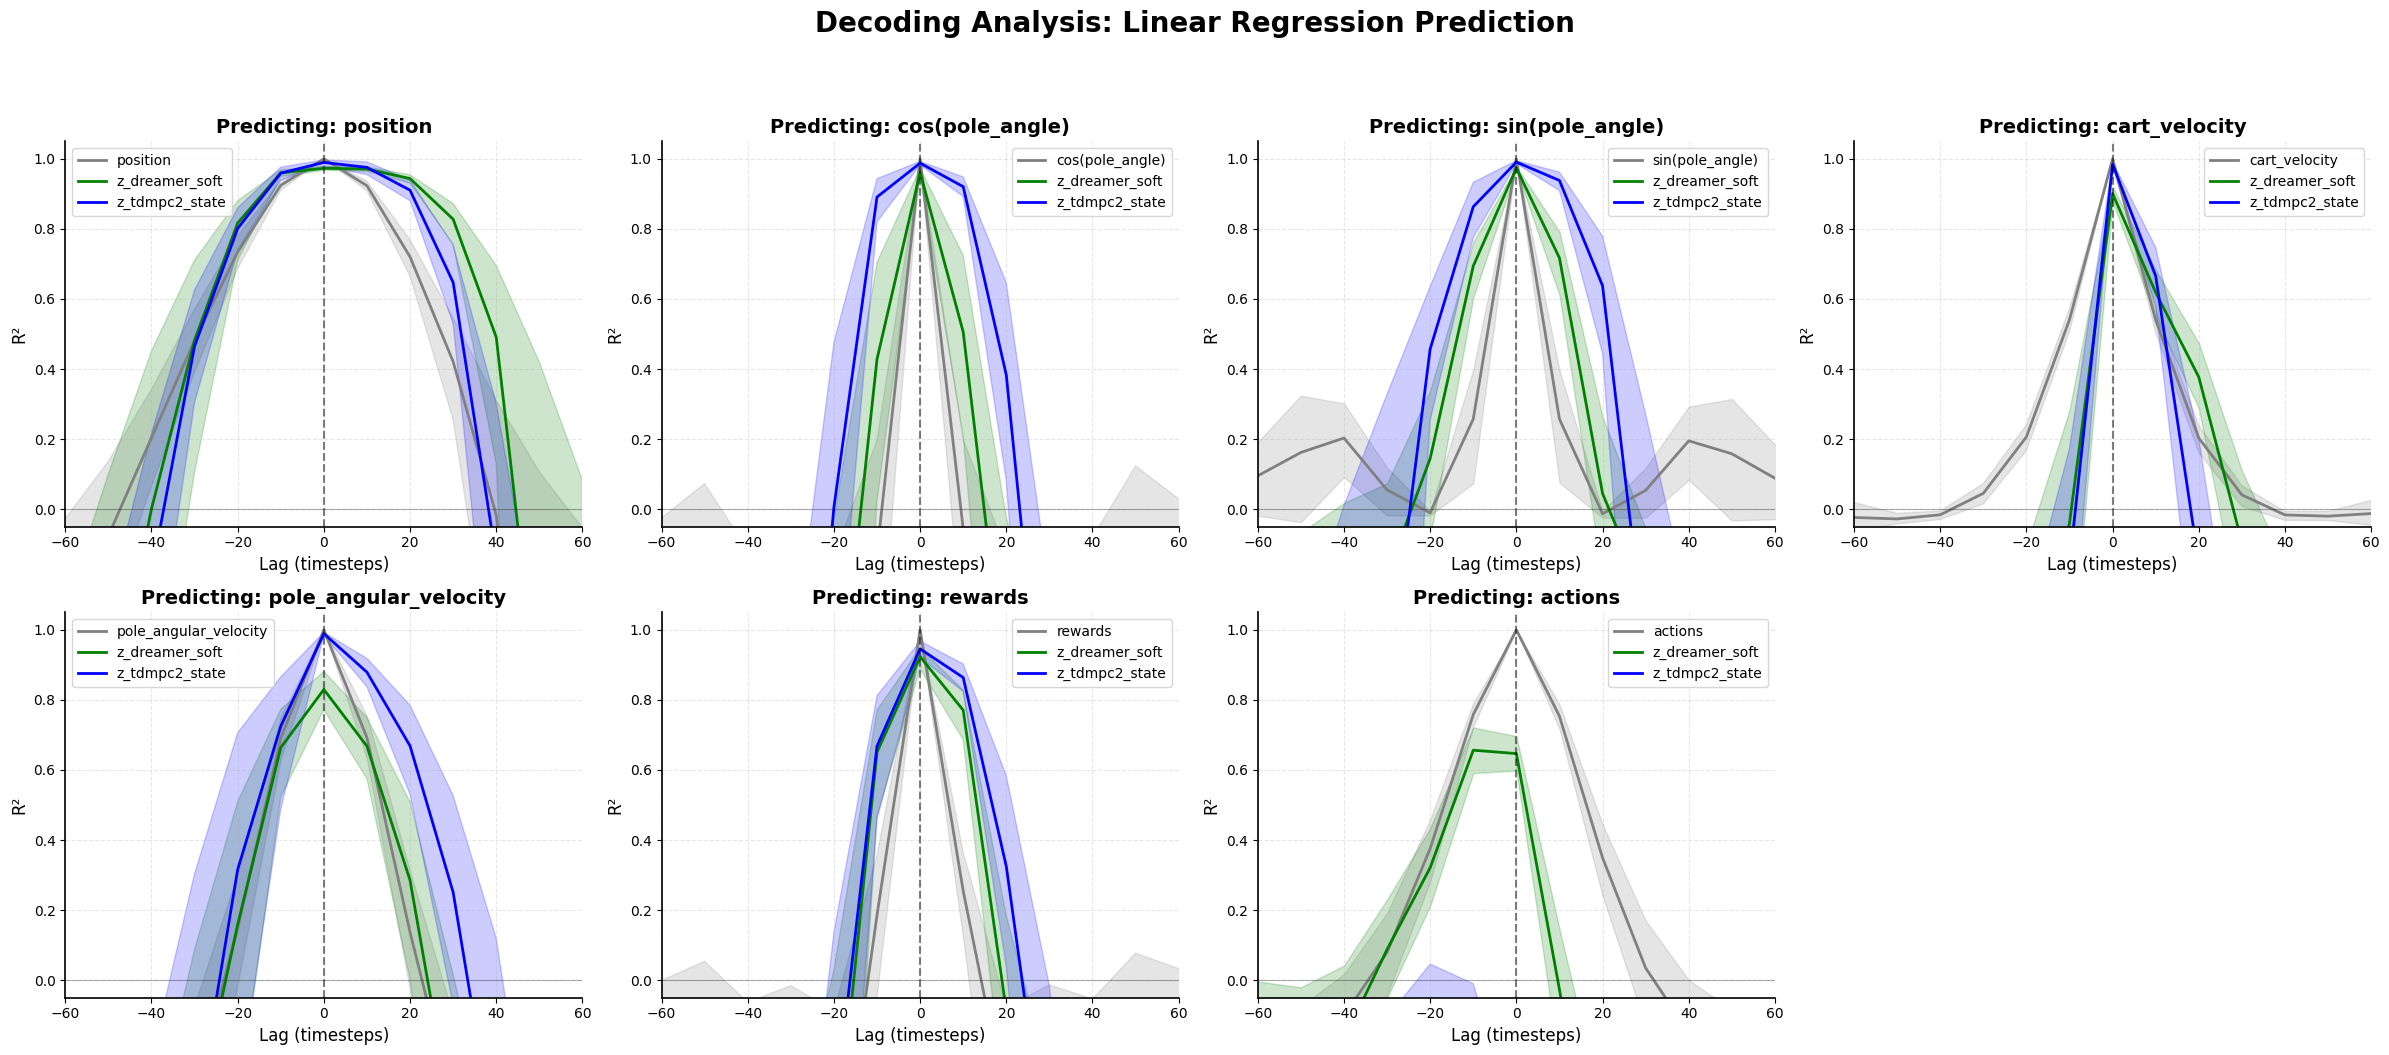

In [17]:
# Group plot keys by y variable
y_variables = [
    'position',
    'cos(pole_angle)',
    'sin(pole_angle)',
    'cart_velocity',
    'pole_angular_velocity',
    'rewards',
    'actions',
]

# Create figure with 2 rows and enough columns for all y variables
n_vars = len(y_variables)
n_cols = (n_vars + 1) // 2  # Ceiling division to get number of columns needed
fig, axes = plt.subplots(2, n_cols, figsize=(n_cols * 6, 10))
axes = axes.flatten()  # Flatten to make indexing easier

# Define colors for each x variable type
color_map = {
    'z_tdmpc2_state': 'blue',
    'z_dreamer_soft': 'green',
    'position': 'gray',
    'cos(pole_angle)': 'gray',
    'sin(pole_angle)': 'gray',
    'cart_velocity': 'gray',
    'pole_angular_velocity': 'gray',
    'rewards': 'gray',
    'actions': 'gray'
}

for idx, y_var in enumerate(y_variables):
    # Get all x variables that predict this y variable
    plot_keys = [(x_var, y_var)
                 for x_var, y_var_check in decoding_relationships
                 if y_var_check == y_var]

    if not plot_keys:
        continue

    ax = axes[idx]

    # Plot each x variable as a separate line
    for x_var, _ in plot_keys:
        key = f'{x_var}-{y_var}'

        if key in results_decoding_all:
            results = results_decoding_all[key]
            r2_mean = results['r2_mean' if not 'dreamer' in
                              key else 'test_r2_mean']
            r2_ci = results['r2_ci' if not 'dreamer' in key else 'test_r2_ci']
            lags = list(r2_mean.keys())
            means = list(r2_mean.values())
            ci_lower = [r2_ci[lag][0] for lag in lags]
            ci_upper = [r2_ci[lag][1] for lag in lags]

            color = color_map.get(x_var, 'black')
            ax.plot(lags, means, linewidth=2, label=x_var, color=color)
            ax.fill_between(lags, ci_lower, ci_upper, alpha=0.2, color=color)

    ax.set_xlabel('Lag (timesteps)', fontsize=12)
    ax.set_ylabel('R²', fontsize=12)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.axvline(x=0, color='k', linestyle='--', alpha=0.5, linewidth=1.5)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-60, 60)
    ax.tick_params(labelsize=10)
    ax.set_title(f'Predicting: {y_var}', fontsize=14, fontweight='bold')
    ax.legend(fontsize=10)

    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Hide any unused subplots
for idx in range(len(y_variables), len(axes)):
    axes[idx].set_visible(False)

# Add overall title
fig.suptitle(f'Decoding Analysis: Linear Regression Prediction',
             fontsize=20,
             fontweight='bold',
             y=1.05)

plt.tight_layout()
sns.despine()
plt.show()